<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/data_visualization/data_vis_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("/content/drive/MyDrive/AI-python/lecture10/sales_training_data.xlsx")
print(df)

          Date Product  Units  Price
0   2025-01-01  Laptop      2  50000
1   2025-01-02  Mobile      3  20000
2   2025-01-03  Tablet      4  15000
3   2025-01-04  Laptop      1  50000
4   2025-01-05  Mobile      5  20000
5   2025-01-06  Tablet      2  15000
6   2025-01-07  Laptop      3  50000
7   2025-01-08  Mobile      2  20000
8   2025-01-09  Tablet      1  15000
9   2025-01-10  Laptop      4  50000
10  2025-01-11  Mobile      3  20000
11  2025-01-12  Tablet      5  15000
12  2025-01-13  Laptop      2  50000
13  2025-01-14  Mobile      1  20000
14  2025-01-15  Tablet      3  15000
15  2025-01-16  Laptop      5  50000
16  2025-01-17  Mobile      4  20000
17  2025-01-18  Tablet      2  15000
18  2025-01-19  Laptop      1  50000
19  2025-01-20  Mobile      2  20000
20  2025-01-21  Tablet      4  15000
21  2025-01-22  Laptop      3  50000
22  2025-01-23  Mobile      5  20000
23  2025-01-24  Tablet      1  15000
24  2025-01-25  Laptop      2  50000
25  2025-01-26  Mobile      3  20000
2

In [4]:
df.shape

(30, 4)

In [5]:
df.columns

Index(['Date', 'Product', 'Units', 'Price'], dtype='object')

In [6]:
df.dtypes

,0
Date,object
Product,object
Units,int64
Price,int64


In [7]:
df.describe()

,Units,Price
count,30.000000,30.000000
mean,2.900000,28333.333333
std,1.348051,15720.255621
min,1.000000,15000.000000
25%,2.000000,15000.000000
50%,3.000000,20000.000000
75%,4.000000,50000.000000
max,5.000000,50000.000000


In [8]:
units = np.array(df["Units"])
price = np.array(df["Price"])

In [9]:
revenue = units * price
print(revenue)

[100000  60000  60000  50000 100000  30000 150000  40000  15000 200000
  60000  75000 100000  20000  45000 250000  80000  30000  50000  40000
  60000 150000 100000  15000 100000  60000  75000 200000  40000  45000]


In [28]:
print("Total Revenue:", np.sum(revenue))
print("Average Revenue:", np.mean(revenue))
print("Min Revenue:", np.min(revenue))
print("Max Revenue:", np.max(revenue))
print("Std Dev:", np.std(revenue))

Total Revenue: 2400000
Average Revenue: 80000.0
Min Revenue: 15000
Max Revenue: 250000
Std Dev: 57052.60730238365


In [29]:
print(np.sort(revenue))
print(np.unique(df["Product"]))

[ 15000  15000  20000  30000  30000  40000  40000  40000  45000  45000
  50000  50000  60000  60000  60000  60000  60000  75000  75000  80000
 100000 100000 100000 100000 100000 150000 150000 200000 200000 250000]
['Laptop' 'Mobile' 'Tablet']


In [30]:
df["Revenue"] = revenue
print(df)

          Date Product  Units  Price  Revenue
0   2025-01-01  Laptop      2  50000   100000
1   2025-01-02  Mobile      3  20000    60000
2   2025-01-03  Tablet      4  15000    60000
3   2025-01-04  Laptop      1  50000    50000
4   2025-01-05  Mobile      5  20000   100000
5   2025-01-06  Tablet      2  15000    30000
6   2025-01-07  Laptop      3  50000   150000
7   2025-01-08  Mobile      2  20000    40000
8   2025-01-09  Tablet      1  15000    15000
9   2025-01-10  Laptop      4  50000   200000
10  2025-01-11  Mobile      3  20000    60000
11  2025-01-12  Tablet      5  15000    75000
12  2025-01-13  Laptop      2  50000   100000
13  2025-01-14  Mobile      1  20000    20000
14  2025-01-15  Tablet      3  15000    45000
15  2025-01-16  Laptop      5  50000   250000
16  2025-01-17  Mobile      4  20000    80000
17  2025-01-18  Tablet      2  15000    30000
18  2025-01-19  Laptop      1  50000    50000
19  2025-01-20  Mobile      2  20000    40000
20  2025-01-21  Tablet      4  150

In [31]:
product_summary = df.groupby("Product")["Revenue"].sum()
print(product_summary)

Product
Laptop    1350000
Mobile     600000
Tablet     450000
Name: Revenue, dtype: int64


In [24]:
df.to_csv("processed_sales_file.csv", index=False)
print("Process CSV file is created")

Process CSV file is created


In [27]:
print(product_summary)

Product
Laptop    1350000
Mobile     600000
Tablet     450000
Name: Revenue, dtype: int64


In [34]:
product = product_summary.index
revenue = product_summary.values


In [35]:
print(product)
print(revenue)

Index(['Laptop', 'Mobile', 'Tablet'], dtype='object', name='Product')
[1350000  600000  450000]


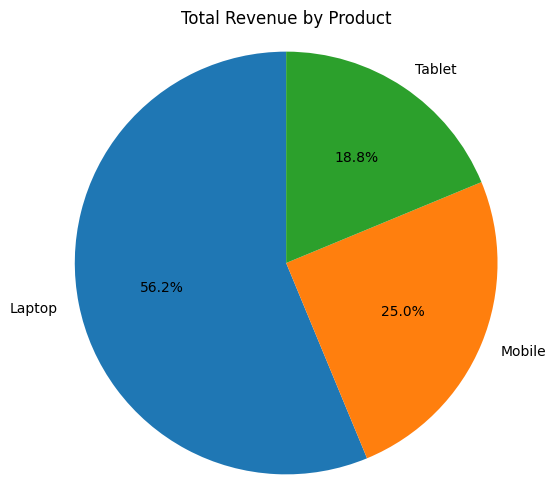

In [36]:
plt.figure(figsize=(6,6))
plt.pie(revenue, labels=product, autopct='%1.1f%%', startangle=90)
plt.title("Total Revenue by Product")
plt.axis('equal')
plt.show()

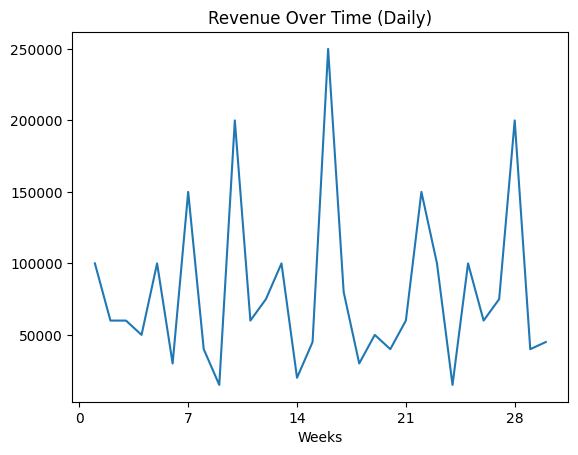

In [38]:
df['Date'] = pd.to_datetime(df['Date'])
day_numbers = df['Date'].dt.day

plt.plot(day_numbers, df["Revenue"])
plt.xlabel("Weeks")
plt.xticks(ticks=[0, 7, 14, 21, 28], labels=['0', '7', '14', '21', '28'])
plt.title("Revenue Over Time (Daily)")
plt.show()